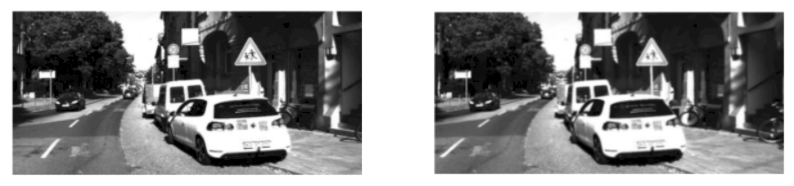

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 7 0 0]
 ...
 [0 0 0 ... 7 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


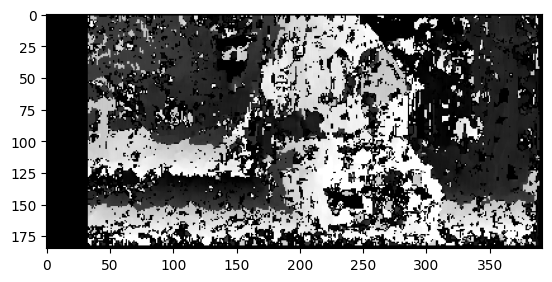

In [36]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
%matplotlib inline

imleft = cv2.imread("Leftimg6.png", 0)
imright = cv2.imread("Rightimg6.png", 0)
imright = cv2.resize(imright, (imleft.shape[1], imleft.shape[0]))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imleft, 'gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(imright, 'gray')
plt.axis('off')
plt.show()

def showdisparity(bsize = 5):
    stereo = cv2.StereoBM_create(numDisparities = 32, blockSize = bsize)
    disparity = stereo.compute(imleft, imright)
    max = disparity.max()
    min = disparity.min()
    disparity = np.uint8(255 * (disparity - min)/(max - min))
    return disparity

result = showdisparity(5)
plt.imshow(result, 'gray')
print(result)
value = result[100][100]
x, y = 100, 100 + value
for r in range(10):
    for c in range(10):
        imleft[100 + r][100 + c] = 0
        imleft[100 + r][100 - c] = 0
        imleft[100 - r][100 + c] = 0
        imleft[100 - r][100 - c] = 0
        imright[x + r][y + c] = 0
        imright[x + r][y - c] = 0
        imright[x - r][y + c] = 0
        imright[x - r][y - c] = 0
for i in range(imright.shape[0]):
    for j in range(imright.shape[1]):
        if (imright[i][j] == 0):
            continue
        imright[i][j] = 1

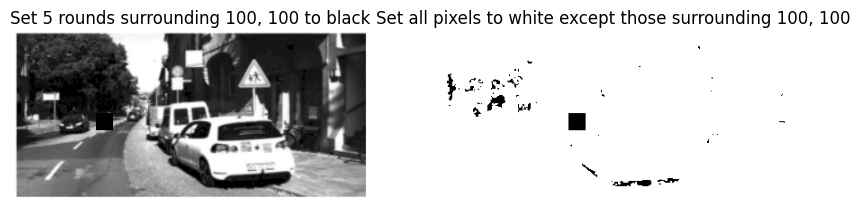

In [37]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imleft, 'gray')
plt.axis('off')
plt.title("Set 5 rounds surrounding 100, 100 to black")
plt.subplot(1, 2, 2)
plt.imshow(imright, 'gray')
plt.axis('off')
plt.title("Set all pixels to white except those surrounding 100, 100")
plt.show()
